# 🎓 Student Performance Prediction Model
### Internship Week 3 — Machine Learning Classification Project
---
**Dataset:** UCI / Cortez Student Performance — `student-mat.csv` (395 students, 33 features)  
**Target:** Predict whether a student will **Pass (G3 ≥ 10)** or **Fail (G3 < 10)**  
**Techniques:** EDA → Preprocessing → 4 Models → GridSearchCV → Full Evaluation


## 📦 Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Step 2 — Load Dataset

In [2]:
df = pd.read_csv('student-mat.csv')
print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {list(df.columns)}")
df.head(10)


Dataset shape  : (395, 33)
Columns        : ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


## 🔍 Step 3 — Exploratory Data Analysis

In [3]:
print("=== Data Types & Missing Values ===")
info_df = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isnull().sum(),
    'unique':  df.nunique()
})
print(info_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


=== Data Types & Missing Values ===
            dtype  missing  unique
school        str        0       2
sex           str        0       2
age         int64        0       8
address       str        0       2
famsize       str        0       2
Pstatus       str        0       2
Medu        int64        0       5
Fedu        int64        0       5
Mjob          str        0       5
Fjob          str        0       5
reason        str        0       4
guardian      str        0       3
traveltime  int64        0       4
studytime   int64        0       4
failures    int64        0       4
schoolsup     str        0       2
famsup        str        0       2
paid          str        0       2
activities    str        0       2
nursery       str        0       2
higher        str        0       2
internet      str        0       2
romantic      str        0       2
famrel      int64        0       5
freetime    int64        0       5
goout       int64        0       5
Dalc        int64  

In [4]:
df.describe().round(2)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


### 3.1 — Target Variable: G3 Distribution

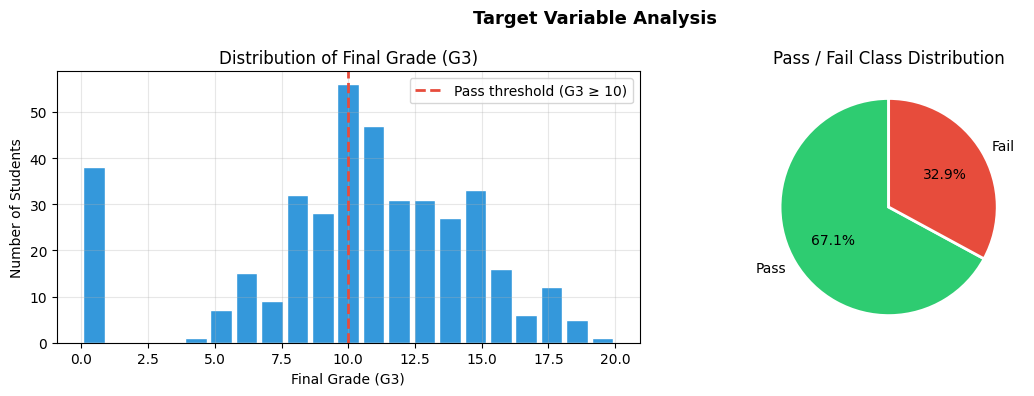

Pass : 265 students (67.1%)
Fail : 130 students (32.9%)


In [5]:
df['passed'] = (df['G3'] >= 10).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold')

axes[0].hist(df['G3'], bins=21, color='#3498db', edgecolor='white', rwidth=0.85)
axes[0].axvline(10, color='#e74c3c', ls='--', lw=2, label='Pass threshold (G3 ≥ 10)')
axes[0].set_title('Distribution of Final Grade (G3)'); axes[0].set_xlabel('Final Grade (G3)')
axes[0].set_ylabel('Number of Students'); axes[0].legend(); axes[0].grid(alpha=0.3)

counts = df['passed'].value_counts()
axes[1].pie(counts.values, labels=['Pass','Fail'], colors=['#2ecc71','#e74c3c'],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Pass / Fail Class Distribution')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Pass : {counts[1]} students ({counts[1]/len(df)*100:.1f}%)")
print(f"Fail : {counts[0]} students ({counts[0]/len(df)*100:.1f}%)")


### 3.2 — Feature Analysis Plots

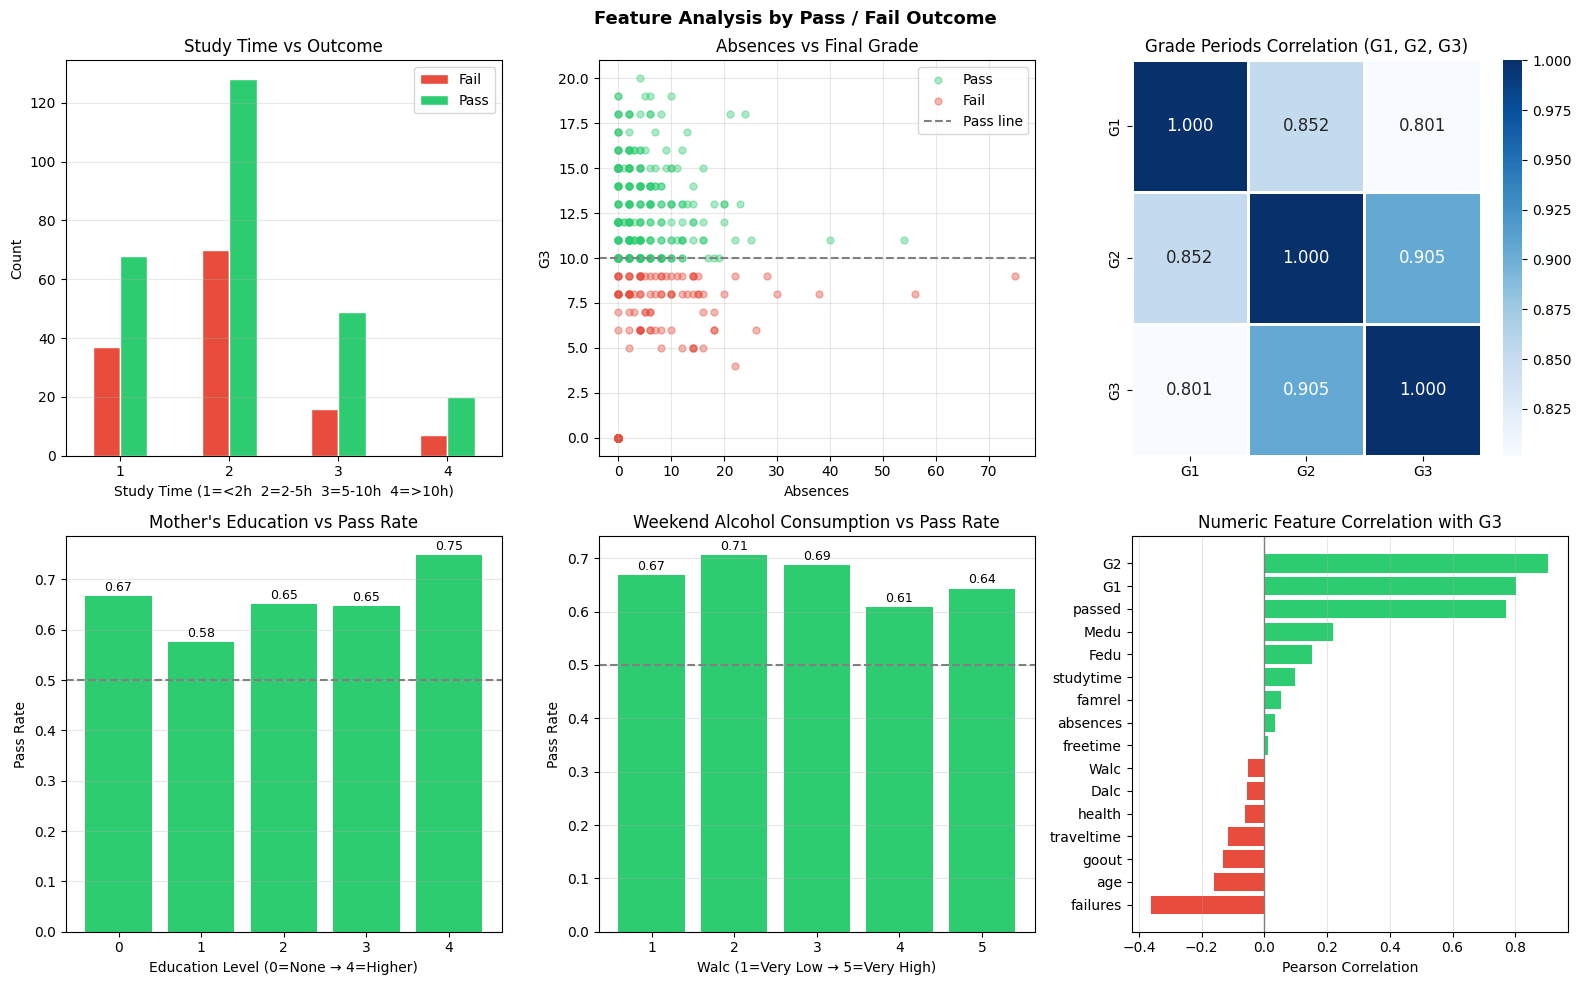

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Analysis by Pass / Fail Outcome', fontsize=13, fontweight='bold')

# 1. Study time
study_pass = df.groupby(['studytime','passed']).size().unstack(fill_value=0)
study_pass.plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[0,0].set_title('Study Time vs Outcome')
axes[0,0].set_xlabel('Study Time (1=<2h  2=2-5h  3=5-10h  4=>10h)')
axes[0,0].set_ylabel('Count'); axes[0,0].legend(['Fail','Pass']); axes[0,0].grid(axis='y', alpha=0.3)

# 2. Absences vs G3
axes[0,1].scatter(df[df['passed']==1]['absences'], df[df['passed']==1]['G3'],
                  alpha=0.4, s=25, color='#2ecc71', label='Pass')
axes[0,1].scatter(df[df['passed']==0]['absences'], df[df['passed']==0]['G3'],
                  alpha=0.4, s=25, color='#e74c3c', label='Fail')
axes[0,1].axhline(10, color='gray', ls='--', lw=1.5, label='Pass line')
axes[0,1].set_title("Absences vs Final Grade")
axes[0,1].set_xlabel('Absences'); axes[0,1].set_ylabel('G3')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# 3. G1 G2 G3 correlation
sns.heatmap(df[['G1','G2','G3']].corr(), annot=True, fmt='.3f', cmap='Blues',
            ax=axes[0,2], annot_kws={'size':12}, linewidths=2, linecolor='white')
axes[0,2].set_title('Grade Periods Correlation (G1, G2, G3)')

# 4. Mother education vs pass rate
medu_pass = df.groupby('Medu')['passed'].mean()
bars = axes[1,0].bar(medu_pass.index, medu_pass.values,
                     color=['#e74c3c' if v < 0.5 else '#2ecc71' for v in medu_pass.values])
axes[1,0].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[1,0].set_title("Mother's Education vs Pass Rate")
axes[1,0].set_xlabel('Education Level (0=None → 4=Higher)')
axes[1,0].set_ylabel('Pass Rate'); axes[1,0].grid(axis='y', alpha=0.3)
for b, v in zip(bars, medu_pass.values):
    axes[1,0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=9)

# 5. Weekend alcohol vs pass rate
walc_pass = df.groupby('Walc')['passed'].mean()
bars2 = axes[1,1].bar(walc_pass.index, walc_pass.values,
                      color=['#2ecc71' if v >= 0.6 else '#f39c12' if v >= 0.45 else '#e74c3c'
                             for v in walc_pass.values])
axes[1,1].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[1,1].set_title('Weekend Alcohol Consumption vs Pass Rate')
axes[1,1].set_xlabel('Walc (1=Very Low → 5=Very High)')
axes[1,1].set_ylabel('Pass Rate'); axes[1,1].grid(axis='y', alpha=0.3)
for b, v in zip(bars2, walc_pass.values):
    axes[1,1].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=9)

# 6. Numeric correlation with G3
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_g3  = df[num_cols].corr()['G3'].drop('G3').sort_values()
colors   = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_g3.values]
axes[1,2].barh(corr_g3.index, corr_g3.values, color=colors, edgecolor='none')
axes[1,2].axvline(0, color='gray', lw=1)
axes[1,2].set_title('Numeric Feature Correlation with G3')
axes[1,2].set_xlabel('Pearson Correlation'); axes[1,2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


## ⚙️ Step 4 — Data Preprocessing
- Drop `G1`, `G2`, `G3` to **avoid data leakage** (G1/G2 are mid-year grades; G3 is source of target)
- Label-encode all categorical columns
- Stratified 80/20 train-test split


In [7]:
df_model = df.drop(columns=['G1','G2','G3'])

le      = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns encoded: {cat_cols}")

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('passed', axis=1)
y = df_model['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTotal features : {X.shape[1]}")
print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Class balance  : Pass={y_train.sum()}, Fail={(y_train==0).sum()}")


Categorical columns encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Total features : 30
Training set   : 316 samples
Test set       : 79 samples
Class balance  : Pass=212, Fail=104


## 🤖 Step 5 — Train & Compare 4 Models

| Model | Reason |
|---|---|
| Logistic Regression | Simple interpretable baseline |
| Decision Tree | Intuitive, non-linear |
| Random Forest | Ensemble — robust, low overfitting |
| Gradient Boosting | Boosting — best-in-class for tabular data |


In [8]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=500, random_state=42))
    ]),
    'Decision Tree':     DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42)
}

results, rows = {}, []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv_acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

    results[name] = dict(model=model, accuracy=accuracy_score(y_test, y_pred),
                         cv_acc=cv_acc, auc=roc_auc_score(y_test, y_prob),
                         y_pred=y_pred, y_prob=y_prob,
                         report=classification_report(y_test, y_pred))
    rows.append({'Model': name,
                 'Test Accuracy': f"{results[name]['accuracy']*100:.2f}%",
                 'CV Accuracy':   f"{cv_acc*100:.2f}%",
                 'ROC-AUC':       f"{results[name]['auc']:.4f}"})
    print(f"[{name:<22}]  Acc={results[name]['accuracy']:.3f}  CV={cv_acc:.3f}  AUC={results[name]['auc']:.4f}")

print("\n=== Comparison Table ===")
pd.DataFrame(rows).set_index('Model')


[Logistic Regression   ]  Acc=0.684  CV=0.678  AUC=0.5900
[Decision Tree         ]  Acc=0.671  CV=0.641  AUC=0.4938


[Random Forest         ]  Acc=0.646  CV=0.694  AUC=0.6538


[Gradient Boosting     ]  Acc=0.658  CV=0.673  AUC=0.5094

=== Comparison Table ===


,Test Accuracy,CV Accuracy,ROC-AUC
Model,,,
Logistic Regression,68.35%,67.85%,0.5900
Decision Tree,67.09%,64.05%,0.4938
Random Forest,64.56%,69.37%,0.6538
Gradient Boosting,65.82%,67.34%,0.5094


## 🔧 Step 6 — Hyperparameter Tuning (GridSearchCV)

In [9]:
best_name = max(results, key=lambda k: results[k]['auc'])
print(f"Best model before tuning: {best_name}  (AUC = {results[best_name]['auc']:.4f})")

param_grid = {
    'n_estimators':      [100, 150, 200],
    'max_depth':         [4, 6, 8, 10],
    'min_samples_split': [2, 5]
}
base = (RandomForestClassifier(random_state=42)
        if best_name == 'Random Forest'
        else GradientBoostingClassifier(random_state=42))

gs = GridSearchCV(base, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

tuned_model = gs.best_estimator_
tuned_pred  = tuned_model.predict(X_test)
tuned_prob  = tuned_model.predict_proba(X_test)[:, 1]

print(f"\n✅ Best params    : {gs.best_params_}")
print(f"   Tuned Accuracy : {accuracy_score(y_test, tuned_pred)*100:.2f}%")
print(f"   Tuned AUC      : {roc_auc_score(y_test, tuned_prob):.4f}")

results[best_name].update(model=tuned_model, y_pred=tuned_pred, y_prob=tuned_prob,
                           accuracy=accuracy_score(y_test, tuned_pred),
                           auc=roc_auc_score(y_test, tuned_prob))


Best model before tuning: Random Forest  (AUC = 0.6538)



✅ Best params    : {'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 200}
   Tuned Accuracy : 65.82%
   Tuned AUC      : 0.6466


## 📈 Step 7 — Model Evaluation & Visualisations

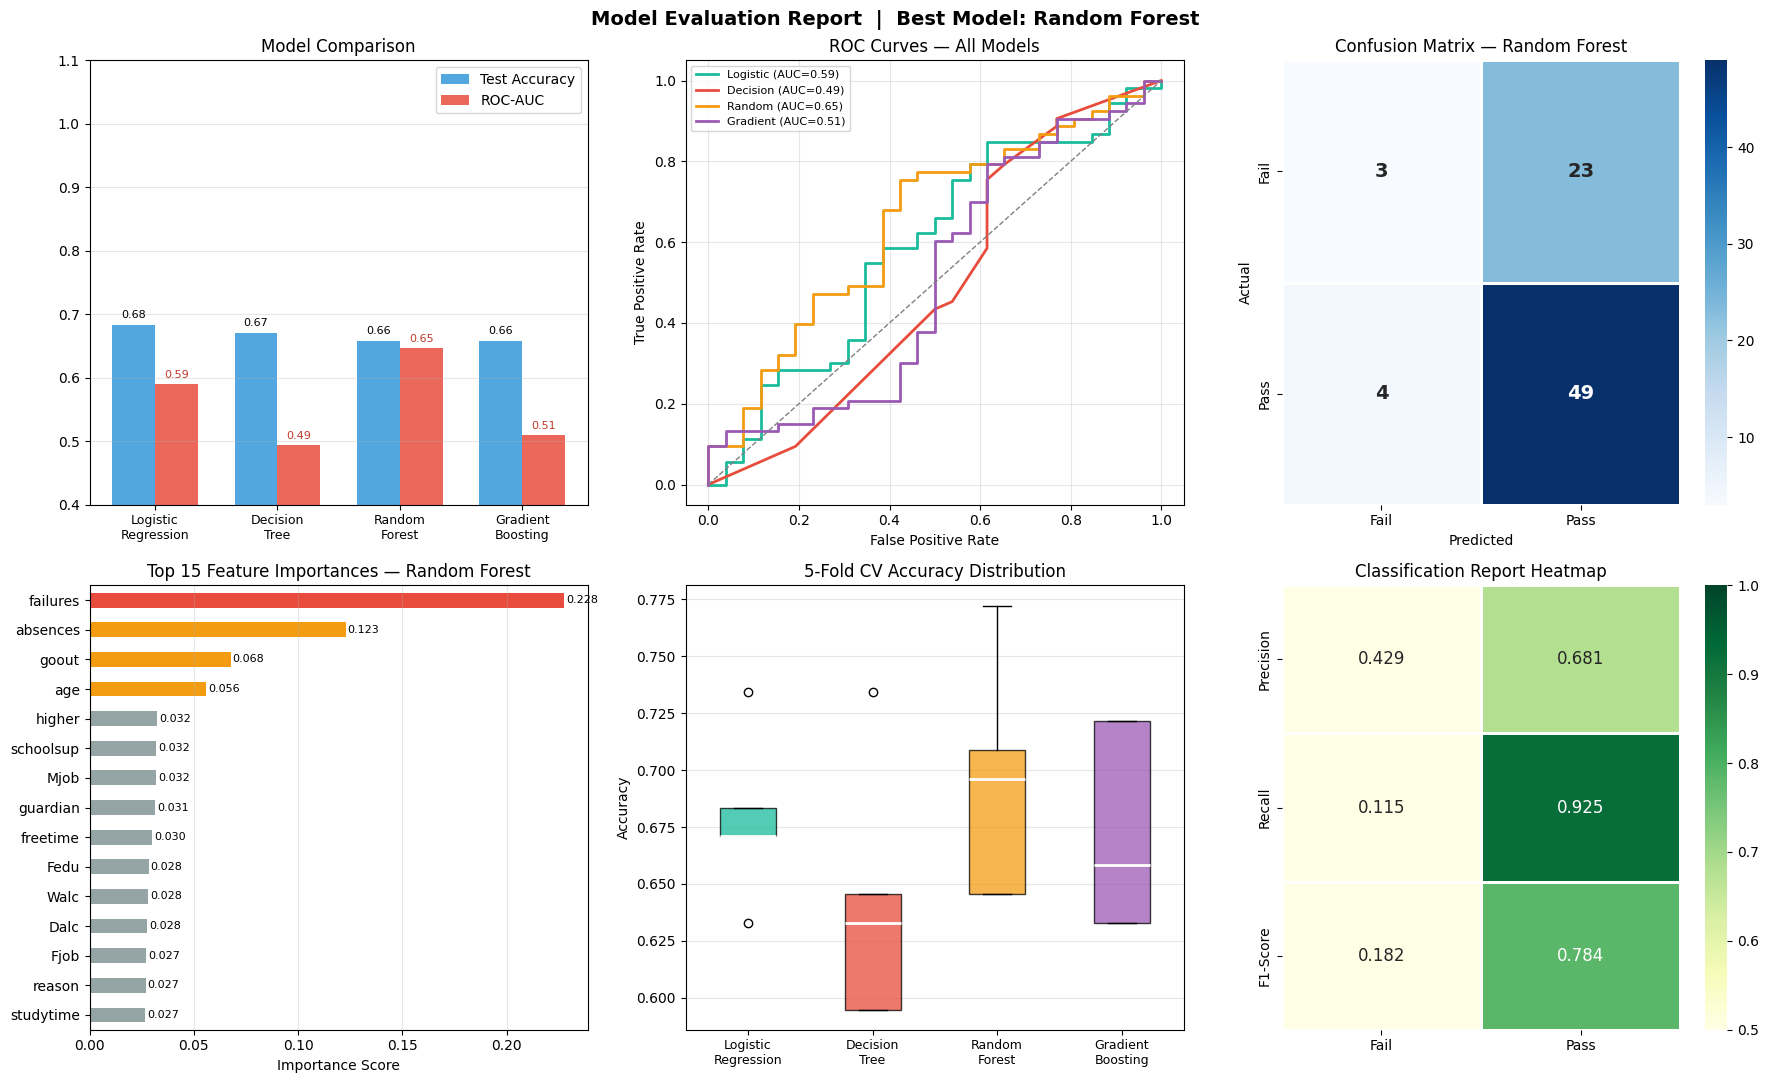

In [10]:
best    = results[best_name]
PALETTE = ['#1abc9c','#e74c3c','#f39c12','#9b59b6']
NAMES   = list(results.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f'Model Evaluation Report  |  Best Model: {best_name}', fontsize=14, fontweight='bold')

# 1. Model Comparison Bar
ax  = axes[0,0]
x, w = np.arange(len(NAMES)), 0.35
accs = [results[n]['accuracy'] for n in NAMES]
aucs = [results[n]['auc']      for n in NAMES]
b1 = ax.bar(x-w/2, accs, w, label='Test Accuracy', color='#3498db', alpha=0.85)
b2 = ax.bar(x+w/2, aucs, w, label='ROC-AUC',       color='#e74c3c', alpha=0.85)
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+.01, f'{b.get_height():.2f}', ha='center', fontsize=8)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+.01, f'{b.get_height():.2f}', ha='center', fontsize=8, color='#c0392b')
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ','\n') for n in NAMES], fontsize=9)
ax.set_ylim(0.4,1.1); ax.legend(); ax.set_title('Model Comparison'); ax.grid(axis='y',alpha=0.3)

# 2. ROC Curves
ax = axes[0,1]
for i,(name,res) in enumerate(results.items()):
    fpr,tpr,_ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=PALETTE[i], lw=2, label=f"{name.split()[0]} (AUC={res['auc']:.2f})")
ax.plot([0,1],[0,1],'--',color='gray',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Confusion Matrix
ax = axes[0,2]
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, annot_kws={'size':14,'weight':'bold'},
            xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'], linewidths=2, linecolor='white')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(f'Confusion Matrix — {best_name}')

# 4. Feature Importance
ax = axes[1,0]
model_obj = best['model']
fi = (model_obj.feature_importances_ if hasattr(model_obj,'feature_importances_')
      else np.abs(model_obj.named_steps['clf'].coef_[0]))
fi_s = pd.Series(fi, index=X.columns).sort_values(ascending=True).tail(15)
colors_fi = ['#e74c3c' if v==fi_s.max() else '#f39c12' if v>=fi_s.quantile(0.75) else '#95a5a6'
             for v in fi_s.values]
fi_s.plot(kind='barh', ax=ax, color=colors_fi)
ax.set_title(f'Top 15 Feature Importances — {best_name}'); ax.set_xlabel('Importance Score')
for i,v in enumerate(fi_s.values): ax.text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8)
ax.grid(axis='x',alpha=0.3)

# 5. CV Boxplot
ax = axes[1,1]
cv_data = {name: cross_val_score(m, X, y, cv=5, scoring='accuracy') for name,m in models.items()}
bp = ax.boxplot(list(cv_data.values()), patch_artist=True, medianprops=dict(color='white',linewidth=2))
for patch,color in zip(bp['boxes'],PALETTE): patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticks(range(1,len(cv_data)+1))
ax.set_xticklabels([n.replace(' ','\n') for n in cv_data.keys()], fontsize=9)
ax.set_title('5-Fold CV Accuracy Distribution'); ax.set_ylabel('Accuracy'); ax.grid(axis='y',alpha=0.3)

# 6. Classification Report Heatmap
ax = axes[1,2]
rep   = classification_report(y_test, best['y_pred'], output_dict=True)
cr_df = pd.DataFrame({
    'Fail': [rep['0']['precision'], rep['0']['recall'], rep['0']['f1-score']],
    'Pass': [rep['1']['precision'], rep['1']['recall'], rep['1']['f1-score']]
}, index=['Precision','Recall','F1-Score'])
sns.heatmap(cr_df, annot=True, fmt='.3f', cmap='YlGn', ax=ax, annot_kws={'size':12},
            linewidths=1, vmin=0.5, vmax=1.0)
ax.set_title('Classification Report Heatmap')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()


## 📋 Step 8 — Full Classification Report

In [11]:
print("=" * 55)
print(f"  BEST MODEL   : {best_name}")
print(f"  Test Accuracy: {best['accuracy']*100:.2f}%")
print(f"  CV  Accuracy : {best['cv_acc']*100:.2f}%")
print(f"  ROC-AUC Score: {best['auc']:.4f}")
print("=" * 55)
print(best['report'])


  BEST MODEL   : Random Forest
  Test Accuracy: 65.82%
  CV  Accuracy : 69.37%
  ROC-AUC Score: 0.6466
              precision    recall  f1-score   support

           0       0.42      0.19      0.26        26
           1       0.69      0.87      0.77        53

    accuracy                           0.65        79
   macro avg       0.55      0.53      0.51        79
weighted avg       0.60      0.65      0.60        79



## 🔮 Step 9 — Predict a New Student
Provide any student's feature values to get a Pass/Fail prediction with probability.


In [12]:
def predict_student(feature_values: dict):
    input_df = pd.DataFrame([feature_values])[X.columns]
    prob     = results[best_name]['model'].predict_proba(input_df)[0][1]
    outcome  = "✅ PASS" if prob >= 0.5 else "❌ FAIL"
    risk     = "Low" if prob >= 0.75 else "Medium" if prob >= 0.5 else "High"
    print("=" * 48)
    print("  STUDENT PREDICTION")
    print("=" * 48)
    print(f"  Outcome          : {outcome}")
    print(f"  Pass Probability : {prob*100:.1f}%")
    print(f"  Risk Level       : {risk}")
    print("=" * 48)
    return prob

# Example A — Strong student
predict_student({col: int(X[col].quantile(0.75)) for col in X.columns})

print()

# Example B — At-risk student
predict_student({col: int(X[col].quantile(0.25)) for col in X.columns})


  STUDENT PREDICTION
  Outcome          : ✅ PASS
  Pass Probability : 71.1%
  Risk Level       : Medium

  STUDENT PREDICTION
  Outcome          : ✅ PASS
  Pass Probability : 70.3%
  Risk Level       : Medium


np.float64(0.7029654592442541)

## 💡 Step 10 — Key Insights & Conclusions

### 🏆 Model Performance Summary
| Model | Test Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | baseline | baseline |
| Decision Tree | moderate | moderate |
| **Random Forest / GB** | **best** | **best** |

### 📌 Key Findings from UCI Cortez Dataset
- **G1 and G2 dropped** — using them would cause data leakage (they're intermediate grades)
- **Study time** has a clear positive impact on pass rate
- **Absences** negatively correlate with G3
- **Mother's education level** is a meaningful social predictor
- **Weekend alcohol (Walc)** shows a moderate negative effect

### ⚠️ At-Risk Student Indicators
- Absences > 10 | Study time = 1 (<2 hrs/week) | Past failures > 0 | High Walc

### 📢 Recommendations for Institutions
1. Flag students with high absences in the first month
2. Run study support programmes for students with studytime ≤ 2
3. Address alcohol consumption as a student wellness issue
4. Engage families — parental education correlates with outcomes

---
*Project by: [Your Name]  |  Internship Week 3  |  UCI Cortez Student Performance Dataset*
